


# Abnormal Volume Spikes and 48-Hour Price Swings in US Stocks & ETFs

## Finance & Economics Datathon Notebook

### Research Question

**If a stock or ETF has an abnormal volume spike today, is it more likely to experience at least a 5% absolute close-to-close move within the next two trading days?**

### Hypothesis

If trading volume is unusually high relative to a security's recent baseline, that security is more likely to experience a large absolute price move over the next **two trading days**.




## Setup

If needed, run the next cell to install the required libraries in your notebook kernel.


In [4]:
# Uncomment and run if you are missing packages.
# %pip install pandas numpy matplotlib seaborn scipy scikit-learn


In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## Load Dataset

We are using the Kaggle dataset **Price Volume Data for All US Stocks & ETFs**. The dataset usually comes as an extracted folder with two subfolders:

- `Stocks/`
- `ETFs/`

Each file contains daily OHLCV data for one ticker. In this Kaggle dataset, the files are commonly `.txt` files with comma-separated columns.

> Because the dataset is large, do **not** upload it through the Colab file picker. It is better to unzip it into your working directory, Google Drive, or a known local folder first.

This Kaggle snapshot appears to end around **2017-11-10**, so the analysis is based on historical data through that date.


In [6]:
DATASET_ROOT = None
START_DATE = "2008-01-01"
MIN_HISTORY_DAYS = 252 * 3
MIN_LAST_DATE = "2017-01-01"
MIN_PRICE = 5.0
MIN_DOLLAR_VOLUME = 1_000_000
TOP_SECURITIES = 250
MAX_SCAN_FILES = None
USE_CACHE = True
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

VOLUME_SPIKE_THRESHOLD = 2.0
MAJOR_SWING_THRESHOLD = 0.05

RANDOM_STATE = 42


In [7]:
def find_dataset_root(user_path=None):
    """Find the extracted Kaggle dataset folder that contains Stocks/ and ETFs/."""
    candidates = []

    if user_path is not None:
        candidates.append(Path(user_path).expanduser())

    candidates.extend([
        Path.cwd(),
        Path.cwd() / "archive",
        Path.cwd() / "price-volume-data-for-all-us-stocks-etfs",
        Path.cwd() / "input" / "price-volume-data-for-all-us-stocks-etfs",
        Path.home() / "Downloads" / "archive",
        Path.home() / "Downloads" / "price-volume-data-for-all-us-stocks-etfs",
        Path("/content/archive"),
        Path("/content/drive/MyDrive/archive"),
        Path("/content/drive/MyDrive/price-volume-data-for-all-us-stocks-etfs"),
    ])

    for candidate in candidates:
        if candidate.exists() and (candidate / "Stocks").exists() and (candidate / "ETFs").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the extracted dataset folder. Set DATASET_ROOT to the folder that contains Stocks/ and ETFs/."
    )


def build_manifest(dataset_root):
    def collect_files(folder):
        return sorted(list(folder.glob("*.csv")) + list(folder.glob("*.txt")))

    stocks = collect_files(dataset_root / "Stocks")
    etfs = collect_files(dataset_root / "ETFs")

    manifest = pd.concat([
        pd.DataFrame({"path": stocks, "security_type": "Stock"}),
        pd.DataFrame({"path": etfs, "security_type": "ETF"}),
    ], ignore_index=True)

    manifest["ticker"] = manifest["path"].map(lambda p: Path(p).stem.upper())

    if MAX_SCAN_FILES is not None:
        manifest = manifest.iloc[:MAX_SCAN_FILES].copy()

    return manifest


dataset_root = find_dataset_root(DATASET_ROOT)
manifest = build_manifest(dataset_root)

print(f"Dataset root: {dataset_root}")
print(f"Files available for scanning: {len(manifest):,}")
display(manifest.head())


Dataset root: c:\Users\Danny W Chen\Documents\GitHub\stockie\archive
Files available for scanning: 8,539


,path,security_type,ticker
0,c:\Users\Danny W Chen\Documents\GitHub\stockie...,Stock,A.US
1,c:\Users\Danny W Chen\Documents\GitHub\stockie...,Stock,AA.US
2,c:\Users\Danny W Chen\Documents\GitHub\stockie...,Stock,AAAP.US
3,c:\Users\Danny W Chen\Documents\GitHub\stockie...,Stock,AABA.US
4,c:\Users\Danny W Chen\Documents\GitHub\stockie...,Stock,AAC.US


## Dataset Description

This dataset is useful for our question because it gives us **daily price and volume history** for a large universe of U.S. stocks and ETFs.

For this notebook, we define:

- **Abnormal volume spike**: `Volume / prior 20-day average volume >= 2.0`
- **Major 48-hour swing**: the maximum absolute close-to-close move over the next 1 or 2 trading days is at least `5%`

We also make one practical modeling choice: instead of using every single file equally, we first rank securities by recent liquidity and keep the most tradable names. This reduces noise from extremely illiquid microcaps and keeps the notebook runnable during a hackathon.


## Universe Construction

The next cell scans the available ticker files and creates a summary table. This may take a few minutes on first run.

We keep securities that meet all of the following:

1. At least 3 years of history since `START_DATE`
2. Recent data that extends close to the end of this dataset snapshot (2017)
3. Median recent price above a minimum floor
4. Median recent dollar volume above a liquidity floor


In [8]:
UNIVERSE_CACHE = CACHE_DIR / "universe_summary.csv"


def summarize_file(row):
    path = Path(row["path"])
    security_type = row["security_type"]
    ticker = row["ticker"]

    try:
        df = pd.read_csv(path, usecols=["Date", "Open", "High", "Low", "Close", "Volume"])
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date", "Close", "Volume"]).sort_values("Date")
        df = df[df["Date"] >= pd.Timestamp(START_DATE)]

        if df.empty:
            return None

        recent = df.tail(min(len(df), 252))
        dollar_volume = recent["Close"] * recent["Volume"]

        return {
            "ticker": ticker,
            "security_type": security_type,
            "path": str(path),
            "rows": len(df),
            "first_date": df["Date"].min(),
            "last_date": df["Date"].max(),
            "median_close_recent": recent["Close"].median(),
            "median_volume_recent": recent["Volume"].median(),
            "median_dollar_volume_recent": dollar_volume.median(),
        }
    except Exception:
        return None


cache_loaded = False
if USE_CACHE and UNIVERSE_CACHE.exists() and UNIVERSE_CACHE.stat().st_size > 0:
    try:
        universe_summary = pd.read_csv(UNIVERSE_CACHE, parse_dates=["first_date", "last_date"])
        cache_loaded = True
        print("Loaded cached universe summary.")
    except pd.errors.EmptyDataError:
        print("Universe cache file was empty. Rebuilding it now...")

if not cache_loaded:
    records = []
    for _, row in manifest.iterrows():
        summary = summarize_file(row)
        if summary is not None:
            records.append(summary)

    universe_summary = pd.DataFrame(records)
    if universe_summary.empty:
        raise ValueError(
            "No files were summarized successfully. Check that DATASET_ROOT points to the extracted dataset and that the files contain Date/Open/High/Low/Close/Volume columns."
        )
    universe_summary.to_csv(UNIVERSE_CACHE, index=False)

eligible = universe_summary.loc[
    (universe_summary["rows"] >= MIN_HISTORY_DAYS)
    & (universe_summary["last_date"] >= pd.Timestamp(MIN_LAST_DATE))
    & (universe_summary["median_close_recent"] >= MIN_PRICE)
    & (universe_summary["median_dollar_volume_recent"] >= MIN_DOLLAR_VOLUME)
].copy()

selected_universe = eligible.sort_values(
    ["median_dollar_volume_recent", "rows"],
    ascending=[False, False],
).head(TOP_SECURITIES).reset_index(drop=True)

if selected_universe.empty:
    raise ValueError(
        "The universe filter returned 0 securities. Try lowering MIN_PRICE/MIN_DOLLAR_VOLUME, or use an earlier MIN_LAST_DATE for this dataset snapshot."
    )

print(f"Scanned files with usable data: {len(universe_summary):,}")
print(f"Eligible liquid securities:     {len(eligible):,}")
print(f"Selected universe size:         {len(selected_universe):,}")
display(selected_universe.head(10))


Scanned files with usable data: 8,507
Eligible liquid securities:     3,545
Selected universe size:         250


,ticker,security_type,path,rows,first_date,last_date,median_close_recent,median_volume_recent,median_dollar_volume_recent
0,SPY.US,ETF,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2484,2008-01-02,2017-11-10,237.2600,"65,777,928.5000","15,458,398,089.8750"
1,IWM.US,ETF,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2484,2008-01-02,2017-11-10,137.3400,"25,244,386.0000","3,486,063,426.5700"
2,AAPL.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2485,2008-01-02,2017-11-10,144.0200,"24,909,588.0000","3,366,270,163.4850"
3,QQQ.US,ETF,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2485,2008-01-02,2017-11-10,137.2000,"21,681,918.0000","2,998,119,218.2100"
4,AMZN.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2485,2008-01-02,2017-11-10,948.5900,"3,142,703.5000","2,881,567,428.9200"
5,FB.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,1381,2012-05-18,2017-11-10,150.0400,"14,944,880.5000","2,245,430,578.7800"
6,NVDA.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2485,2008-01-02,2017-11-10,130.2300,"15,101,374.5000","2,103,221,121.5100"
7,EEM.US,ETF,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2484,2008-01-02,2017-11-10,40.9105,"48,459,844.0000","2,011,210,254.1800"
8,BAC.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,2485,2008-01-02,2017-11-10,23.5850,"77,708,127.0000","1,849,797,681.5640"
9,TSLA.US,Stock,c:\Users\Danny W Chen\Documents\GitHub\stockie...,1858,2010-06-28,2017-11-10,310.2850,"5,312,149.0000","1,630,390,719.9550"


## Quick Universe Check

Before building the event dataset, we inspect the selected universe to make sure it contains both stocks and ETFs and that the liquidity filter behaved as expected.


Selected universe by security type:


,count
security_type,
Stock,192
ETF,58


Recent dollar-volume summary:


,value
count,250.0000
mean,"527,649,232.4001"
std,"1,062,878,844.7983"
min,"182,000,766.5580"
25%,"222,745,256.4013"
50%,"315,264,596.2575"
75%,"527,101,769.1509"
max,"15,458,398,089.8750"


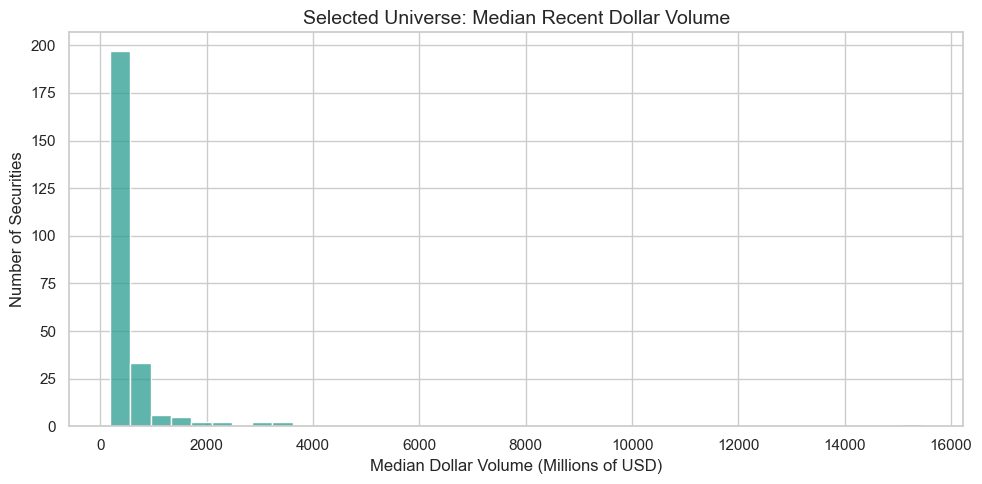

In [9]:
print("Selected universe by security type:")
display(selected_universe["security_type"].value_counts().rename_axis("security_type").to_frame("count"))

print("Recent dollar-volume summary:")
display(selected_universe["median_dollar_volume_recent"].describe().to_frame("value"))

plt.figure(figsize=(10, 5))
sns.histplot(
    selected_universe["median_dollar_volume_recent"] / 1_000_000,
    bins=40,
    color="#2a9d8f",
)
plt.title("Selected Universe: Median Recent Dollar Volume", fontsize=14)
plt.xlabel("Median Dollar Volume (Millions of USD)")
plt.ylabel("Number of Securities")
plt.tight_layout()
plt.show()


## Data Cleaning and Feature Engineering

Now we build the event-level dataset used for the rest of the notebook.

For every ticker and every eligible day, we create:

- `Volume_Ratio`: today's volume divided by the **prior** 20-day average volume
- `Is_Spike`: whether the day qualifies as an abnormal volume spike
- `Future_Max_Abs_Return_48h`: the largest absolute close-to-close move over the next 2 trading days
- `Major_Swing_48h`: whether that future move crosses our chosen threshold
- several control variables for the ML section

Notice that rolling features are shifted when needed so we only use information that would have been known at the time.


In [10]:
EVENT_CACHE = CACHE_DIR / "event_dataset.pkl"


def build_event_frame(path, security_type, ticker):
    df = pd.read_csv(path, usecols=["Date", "Open", "High", "Low", "Close", "Volume"])
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Open", "High", "Low", "Close", "Volume"]).sort_values("Date")
    df = df[df["Date"] >= pd.Timestamp(START_DATE)].copy()

    if len(df) < MIN_HISTORY_DAYS:
        return None

    close_return = df["Close"].pct_change()

    df["Ticker"] = ticker
    df["Security_Type"] = security_type
    df["Dollar_Volume"] = df["Close"] * df["Volume"]
    df["Volume_MA20"] = df["Volume"].rolling(20).mean().shift(1)
    df["Volume_MA20"] = df["Volume_MA20"].replace(0, np.nan)
    df["Volume_Ratio"] = df["Volume"] / df["Volume_MA20"]
    df["Is_Spike"] = (df["Volume_Ratio"] >= VOLUME_SPIKE_THRESHOLD).astype(int)

    df["Past_Return_5d"] = df["Close"] .pct_change(5)
    df["Past_Return_20d"] = df["Close"].pct_change(20)
    df["Volatility_20d"] = close_return.rolling(20).std().shift(1)
    df["Range_Pct"] = (df["High"] - df["Low"]) / df["Close"]
    df["MA20_Close"] = df["Close"].rolling(20).mean().shift(1)
    df["Price_vs_MA20"] = (df["Close"] / df["MA20_Close"]) - 1

    df["Future_Return_1d"] = df["Close"].shift(-1) / df["Close"] - 1
    df["Future_Return_2d"] = df["Close"].shift(-2) / df["Close"] - 1
    df["Future_Max_Abs_Return_48h"] = np.maximum(
        df["Future_Return_1d"].abs(),
        df["Future_Return_2d"].abs(),
    )
    df["Major_Swing_48h"] = (df["Future_Max_Abs_Return_48h"] >= MAJOR_SWING_THRESHOLD).astype(int)

    keep_cols = [
        "Date",
        "Ticker",
        "Security_Type",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Dollar_Volume",
        "Volume_Ratio",
        "Is_Spike",
        "Past_Return_5d",
        "Past_Return_20d",
        "Volatility_20d",
        "Range_Pct",
        "Price_vs_MA20",
        "Future_Return_1d",
        "Future_Return_2d",
        "Future_Max_Abs_Return_48h",
        "Major_Swing_48h",
    ]

    df = df[keep_cols].dropna().copy()
    return df


cache_loaded = False
if USE_CACHE and EVENT_CACHE.exists() and EVENT_CACHE.stat().st_size > 0:
    try:
        analysis_df = pd.read_pickle(EVENT_CACHE)
        cache_loaded = True
        print("Loaded cached event dataset.")
    except Exception:
        print("Event cache could not be read. Rebuilding it now...")

if not cache_loaded:
    frames = []
    for _, row in selected_universe.iterrows():
        frame = build_event_frame(row["path"], row["security_type"], row["ticker"])
        if frame is not None and not frame.empty:
            frames.append(frame)

    if not frames:
        raise ValueError(
            f"No event frames were built from {len(selected_universe)} selected securities. Double-check that the universe cell ran successfully and that the dataset files are readable."
        )

    analysis_df = pd.concat(frames, ignore_index=True)
    analysis_df.to_pickle(EVENT_CACHE)

analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan).dropna().copy()
analysis_df["Is_ETF"] = (analysis_df["Security_Type"] == "ETF").astype(int)
analysis_df["Log_Dollar_Volume"] = np.log1p(analysis_df["Dollar_Volume"])

print(f"Event-level rows: {len(analysis_df):,}")
print(f"Unique tickers:    {analysis_df['Ticker'].nunique():,}")
print(f"Date range:        {analysis_df['Date'].min().date()} to {analysis_df['Date'].max().date()}")
analysis_df.head()


Event-level rows: 586,582
Unique tickers:    250
Date range:        2008-02-01 to 2017-11-08


,Date,Ticker,Security_Type,Open,High,Low,Close,Volume,Dollar_Volume,Volume_Ratio,Is_Spike,Past_Return_5d,Past_Return_20d,Volatility_20d,Range_Pct,Price_vs_MA20,Future_Return_1d,Future_Return_2d,Future_Max_Abs_Return_48h,Major_Swing_48h,Is_ETF,Log_Dollar_Volume
0,2008-02-01,SPY.US,ETF,120.1800,121.6200,119.7900,121.5900,237433741,"28,869,568,568.1900",0.7008,0,0.0491,-0.0366,0.0145,0.0151,0.0165,-0.0125,-0.0389,0.0389,0,1,24.0861
1,2008-02-04,SPY.US,ETF,121.2800,121.3500,119.9000,120.0700,143135256,"17,186,250,187.9200",0.4167,0,0.0193,-0.0246,0.0151,0.0121,0.0058,-0.0267,-0.0346,0.0346,0,1,23.5674
2,2008-02-05,SPY.US,ETF,118.4200,118.7100,116.4400,116.8600,329309394,"38,483,095,782.8400",0.9762,0,-0.0129,-0.0498,0.0143,0.0194,-0.0199,-0.0081,-0.0015,0.0081,0,1,24.3735
3,2008-02-06,SPY.US,ETF,117.2500,117.8100,115.3500,115.9100,287882596,"33,368,471,702.3600",0.8460,0,-0.0138,-0.0421,0.0154,0.0212,-0.0253,0.0066,0.0002,0.0066,0,1,24.2309
4,2008-02-07,SPY.US,ETF,114.8200,117.4100,114.7600,116.6800,341544898,"39,851,458,698.6400",1.0166,0,-0.0249,-0.0460,0.0152,0.0227,-0.0167,-0.0064,-0.0015,0.0064,0,1,24.4084


## Quick Data Check

We will inspect shape, missing values, and class balance before moving into charts and tests.


In [11]:
print("Rows:", len(analysis_df))
print("Columns:", len(analysis_df.columns))
print(f"Volume spike rate: {analysis_df['Is_Spike'].mean():.2%}")
print(f"Major 48h swing rate: {analysis_df['Major_Swing_48h'].mean():.2%}")

missing_pct = (analysis_df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing percentage per column:")
display(missing_pct.to_frame("missing_%"))

print("\nTarget balance by security type:")
display(
    analysis_df.groupby("Security_Type")["Major_Swing_48h"].mean().mul(100).round(2).to_frame("major_swing_rate_%")
)


Rows: 586582
Columns: 22
Volume spike rate: 3.77%
Major 48h swing rate: 9.39%

Missing percentage per column:


,missing_%
Date,0.0000
Ticker,0.0000
Security_Type,0.0000
Open,0.0000
High,0.0000
Low,0.0000
Close,0.0000
Volume,0.0000
Dollar_Volume,0.0000
Volume_Ratio,0.0000



Target balance by security type:


,major_swing_rate_%
Security_Type,
ETF,9.5500
Stock,9.3500


## Exploratory Data Analysis (EDA)

We'll create four charts, each tied directly to the research question:

| Chart | Question |
|-------|----------|
| 1. Histogram | How unusual are large volume spikes in this universe? |
| 2. Bar Chart | Are major 48-hour swings more common after spike days? |
| 3. Line Chart | How large are future moves after spike vs non-spike days? |
| 4. Bucket Analysis | Does prediction strength improve as volume spikes get larger? |

---
> **Tip:** After each chart, read the printed summary before moving on.


---

### Chart 1: Distribution of Volume Ratios

**What we're looking at:** The distribution of `Volume_Ratio`, where `1.0` means today's volume exactly matches the prior 20-day average and values above `2.0` indicate a spike.

**Why it matters:** If the spike threshold is too low or too high, the research question becomes less meaningful. This chart tells us whether `2x average volume` is a rare but still usable event.


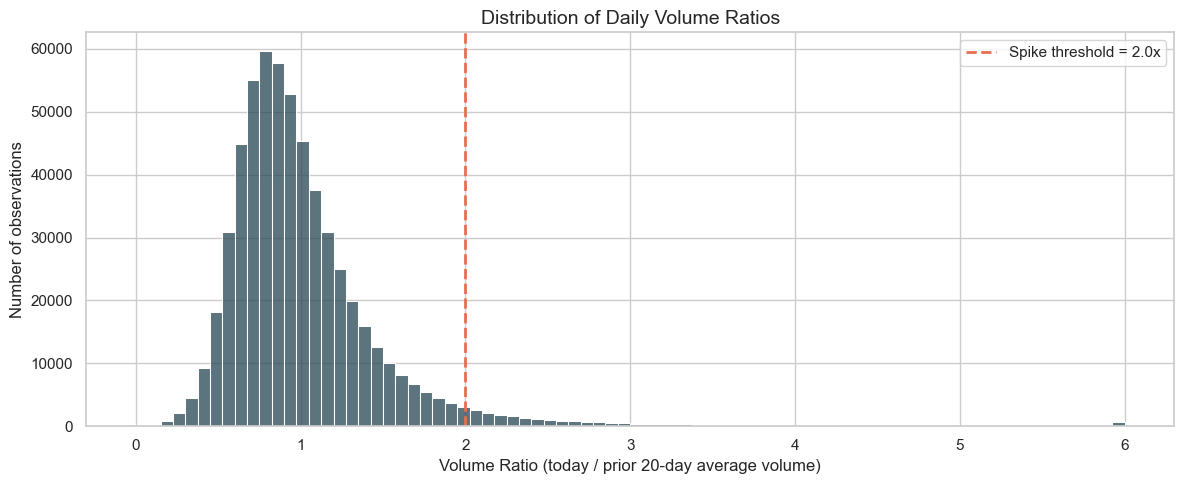

Volume ratio summary:
count   586,582.0000
mean          1.0240
std           0.9220
min           0.0000
50%           0.9130
75%           1.1730
90%           1.5300
95%           1.8500
99%           2.9480
max         540.9010
Name: Volume_Ratio, dtype: float64


In [12]:
finite_volume_ratio = analysis_df.loc[np.isfinite(analysis_df["Volume_Ratio"]), "Volume_Ratio"]

plt.figure(figsize=(12, 5))
sns.histplot(
    finite_volume_ratio.clip(upper=6),
    bins=80,
    color="#264653",
)
plt.axvline(VOLUME_SPIKE_THRESHOLD, color="#e76f51", linestyle="--", linewidth=2, label=f"Spike threshold = {VOLUME_SPIKE_THRESHOLD:.1f}x")
plt.title("Distribution of Daily Volume Ratios", fontsize=14)
plt.xlabel("Volume Ratio (today / prior 20-day average volume)")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

print("Volume ratio summary:")
print(finite_volume_ratio.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(3))


---

### Chart 2: Major Swing Rate After Spike vs Non-Spike Days

**What we're looking at:** The share of observations where a security experiences a major move within the next two trading days, split by whether volume was abnormal on day `t`.

**Why it matters:** This is the simplest visual test of the research question.


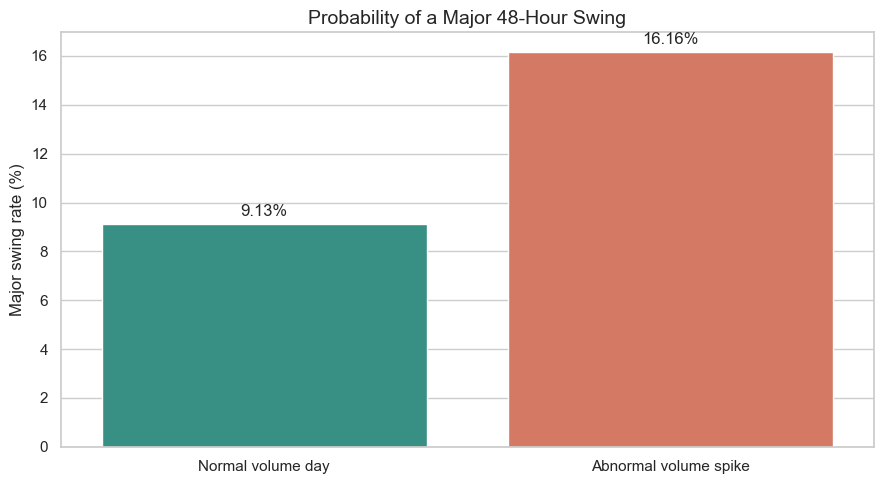

,Event_Type,count,sum,rate_pct
0,Normal volume day,564452,51520,9.1274
1,Abnormal volume spike,22130,3576,16.1591


In [13]:
rate_df = (
    analysis_df.groupby("Is_Spike")["Major_Swing_48h"]
    .agg(["mean", "count", "sum"])
    .rename(index={0: "Normal volume day", 1: "Abnormal volume spike"})
    .reset_index(names="Event_Type")
)
rate_df["rate_pct"] = rate_df["mean"] * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=rate_df,
    x="Event_Type",
    y="rate_pct",
    palette=["#2a9d8f", "#e76f51"],
)
plt.title("Probability of a Major 48-Hour Swing", fontsize=14)
plt.xlabel("")
plt.ylabel("Major swing rate (%)")

for i, row in rate_df.iterrows():
    ax.text(i, row["rate_pct"] + 0.2, f"{row['rate_pct']:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

display(rate_df[["Event_Type", "count", "sum", "rate_pct"]])


---

### Chart 3: Average Future Move Size

**What we're looking at:** The average absolute close-to-close move after day `t`, comparing spike days and normal days over 1 trading day and 2 trading days.

**Why it matters:** Even if the probability of a major swing increases, we also want to know whether the *size* of future moves increases.


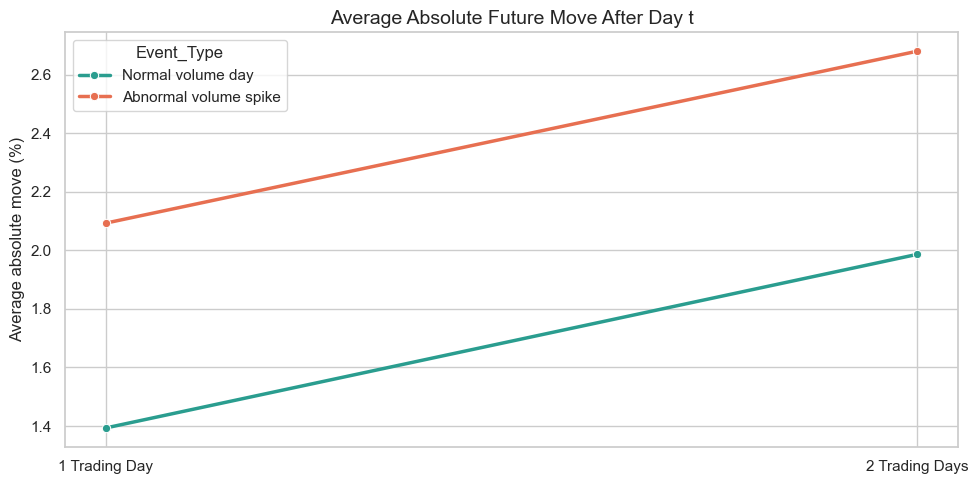

,Horizon,Event_Type,Average_Abs_Move_Pct
0,1 Trading Day,Normal volume day,1.3930
1,2 Trading Days,Normal volume day,1.9870
2,1 Trading Day,Abnormal volume spike,2.0930
3,2 Trading Days,Abnormal volume spike,2.6810


In [14]:
path_summary = pd.DataFrame({
    "Horizon": ["1 Trading Day", "2 Trading Days", "1 Trading Day", "2 Trading Days"],
    "Event_Type": ["Normal volume day", "Normal volume day", "Abnormal volume spike", "Abnormal volume spike"],
    "Average_Abs_Move_Pct": [
        analysis_df.loc[analysis_df["Is_Spike"] == 0, "Future_Return_1d"].abs().mean() * 100,
        analysis_df.loc[analysis_df["Is_Spike"] == 0, "Future_Return_2d"].abs().mean() * 100,
        analysis_df.loc[analysis_df["Is_Spike"] == 1, "Future_Return_1d"].abs().mean() * 100,
        analysis_df.loc[analysis_df["Is_Spike"] == 1, "Future_Return_2d"].abs().mean() * 100,
    ],
})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=path_summary,
    x="Horizon",
    y="Average_Abs_Move_Pct",
    hue="Event_Type",
    marker="o",
    linewidth=2.5,
    palette=["#2a9d8f", "#e76f51"],
)
plt.title("Average Absolute Future Move After Day t", fontsize=14)
plt.xlabel("")
plt.ylabel("Average absolute move (%)")
plt.tight_layout()
plt.show()

display(path_summary.round(3))


---

### Chart 4: Does Stronger Volume = Stronger Signal?

**What we're looking at:** We bucket `Volume_Ratio` values into increasing ranges and compute the major-swing rate for each bucket.

**Why it matters:** If prediction strength rises as volume becomes more extreme, that supports the idea that the relationship is not random noise.


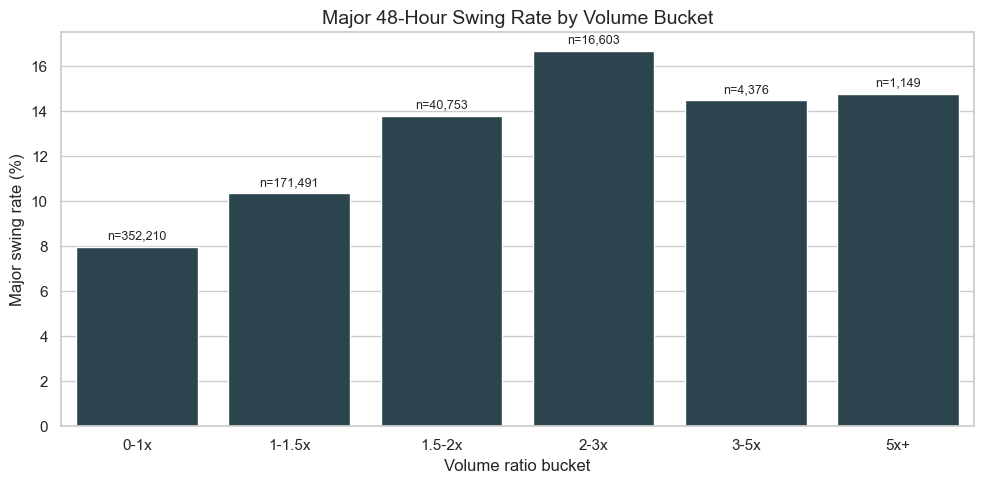

,Volume_Bucket,mean,count,major_swing_rate_pct
0,0-1x,0.0800,352210,7.9840
1,1-1.5x,0.1040,171491,10.3660
2,1.5-2x,0.1380,40753,13.8050
3,2-3x,0.1670,16603,16.6840
4,3-5x,0.1450,4376,14.4880
5,5x+,0.1480,1149,14.7950


In [15]:
bucket_df = analysis_df.copy()
bucket_df["Volume_Bucket"] = pd.cut(
    bucket_df["Volume_Ratio"],
    bins=[0, 1, 1.5, 2, 3, 5, np.inf],
    labels=["0-1x", "1-1.5x", "1.5-2x", "2-3x", "3-5x", "5x+"],
    include_lowest=True,
)

bucket_summary = (
    bucket_df.groupby("Volume_Bucket", observed=False)["Major_Swing_48h"]
    .agg(["mean", "count"])
    .reset_index()
)
bucket_summary["major_swing_rate_pct"] = bucket_summary["mean"] * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=bucket_summary,
    x="Volume_Bucket",
    y="major_swing_rate_pct",
    color="#264653",
)
plt.title("Major 48-Hour Swing Rate by Volume Bucket", fontsize=14)
plt.xlabel("Volume ratio bucket")
plt.ylabel("Major swing rate (%)")

for i, row in bucket_summary.iterrows():
    ax.text(i, row["major_swing_rate_pct"] + 0.2, f"n={int(row['count']):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

display(bucket_summary.round(3))


## Statistical Testing

Visual patterns are helpful, but we also want formal statistical evidence.

We will use two complementary tests:

1. A **difference in proportions** test for the rate of major swings after spike vs non-spike days
2. A **chi-square test of independence** on the full contingency table

This section does **not** claim causation. It only tests whether the observed relationship is stronger than random variation.


In [16]:
contingency = pd.crosstab(analysis_df["Is_Spike"], analysis_df["Major_Swing_48h"])
contingency.index = ["Normal volume day", "Abnormal volume spike"]
contingency.columns = ["No major swing", "Major swing"]

a = contingency.loc["Abnormal volume spike", "Major swing"]
b = contingency.loc["Abnormal volume spike", "No major swing"]
c = contingency.loc["Normal volume day", "Major swing"]
d = contingency.loc["Normal volume day", "No major swing"]

n_spike = a + b
n_normal = c + d
p_spike = a / n_spike
p_normal = c / n_normal
diff = p_spike - p_normal

pooled = (a + c) / (n_spike + n_normal)
se_pooled = np.sqrt(pooled * (1 - pooled) * ((1 / n_spike) + (1 / n_normal)))
z_stat = diff / se_pooled
p_value_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))

se_unpooled = np.sqrt((p_spike * (1 - p_spike) / n_spike) + (p_normal * (1 - p_normal) / n_normal))
ci_low = diff - 1.96 * se_unpooled
ci_high = diff + 1.96 * se_unpooled

chi2, p_value_chi2, dof, expected = stats.chi2_contingency(pd.crosstab(analysis_df["Is_Spike"], analysis_df["Major_Swing_48h"]))
odds_ratio = (a * d) / (b * c)

print("Contingency table:")
display(contingency)

print(f"Major swing rate after spike days:   {p_spike:.2%}")
print(f"Major swing rate after normal days:  {p_normal:.2%}")
print(f"Difference in rates:                 {diff:.2%}")
print(f"95% CI for difference:               [{ci_low:.2%}, {ci_high:.2%}]")
print(f"Two-sided z-test p-value:            {p_value_prop:.6g}")
print(f"Chi-square p-value:                  {p_value_chi2:.6g}")
print(f"Odds ratio:                          {odds_ratio:.3f}")


Contingency table:


,No major swing,Major swing
Normal volume day,512932,51520
Abnormal volume spike,18554,3576


Major swing rate after spike days:   16.16%
Major swing rate after normal days:  9.13%
Difference in rates:                 7.03%
95% CI for difference:               [6.54%, 7.52%]
Two-sided z-test p-value:            0
Chi-square p-value:                  7.62916e-271
Odds ratio:                          1.919


## Baseline Machine Learning Model

Goal: predict whether a security will experience a **major 48-hour swing** using only information available at day `t`.

This is just a simple model, not a trading strategy. We also include other things like volatility and price action to be more realistic.


In [17]:
ml_df = analysis_df.copy()

if "Is_ETF" not in ml_df.columns:
    ml_df["Is_ETF"] = (ml_df["Security_Type"] == "ETF").astype(int)
if "Log_Dollar_Volume" not in ml_df.columns:
    ml_df["Log_Dollar_Volume"] = np.log1p(ml_df["Dollar_Volume"].clip(lower=0))

feature_cols = [
    "Volume_Ratio",
    "Log_Dollar_Volume",
    "Past_Return_5d",
    "Past_Return_20d",
    "Volatility_20d",
    "Range_Pct",
    "Price_vs_MA20",
    "Is_ETF",
]

target_col = "Major_Swing_48h"

for col in feature_cols + [target_col]:
    ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

ml_df = ml_df.replace([np.inf, -np.inf], np.nan)
ml_df = ml_df.dropna(subset=feature_cols + [target_col]).copy()

# Clip extreme tails for model stability while keeping the core research result unchanged.
ml_df["Volume_Ratio"] = ml_df["Volume_Ratio"].clip(lower=0, upper=ml_df["Volume_Ratio"].quantile(0.999))
ml_df["Range_Pct"] = ml_df["Range_Pct"].clip(lower=ml_df["Range_Pct"].quantile(0.001), upper=ml_df["Range_Pct"].quantile(0.999))
ml_df["Past_Return_5d"] = ml_df["Past_Return_5d"].clip(lower=ml_df["Past_Return_5d"].quantile(0.001), upper=ml_df["Past_Return_5d"].quantile(0.999))
ml_df["Past_Return_20d"] = ml_df["Past_Return_20d"].clip(lower=ml_df["Past_Return_20d"].quantile(0.001), upper=ml_df["Past_Return_20d"].quantile(0.999))
ml_df["Price_vs_MA20"] = ml_df["Price_vs_MA20"].clip(lower=ml_df["Price_vs_MA20"].quantile(0.001), upper=ml_df["Price_vs_MA20"].quantile(0.999))

unique_dates = np.sort(ml_df["Date"].unique())
split_idx = int(len(unique_dates) * 0.8)
split_date = pd.Timestamp(unique_dates[split_idx])

train_df = ml_df[ml_df["Date"] <= split_date].copy()
test_df = ml_df[ml_df["Date"] > split_date].copy()

X_train_df = train_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()
y_train = train_df[target_col].astype(int).to_numpy()
y_test = test_df[target_col].astype(int).to_numpy()

X_train = X_train_df.to_numpy(dtype=np.float64)
X_test = X_test_df.to_numpy(dtype=np.float64)

finite_train_mask = np.isfinite(X_train).all(axis=1)
finite_test_mask = np.isfinite(X_test).all(axis=1)

X_train = X_train[finite_train_mask]
y_train = y_train[finite_train_mask]
X_test = X_test[finite_test_mask]
y_test = y_test[finite_test_mask]

print(f"Train rows: {len(X_train):,} | date range: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test rows:  {len(X_test):,} | date range: {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")
print(f"Training target rate: {y_train.mean():.2%}")
print(f"Testing target rate:  {y_test.mean():.2%}")
print(f"All finite in X_train: {np.isfinite(X_train).all()}")
print(f"All finite in X_test:  {np.isfinite(X_test).all()}")

display(pd.DataFrame({"feature": feature_cols, "train_max": X_train.max(axis=0), "train_min": X_train.min(axis=0)}))


Train rows: 463,582 | date range: 2008-02-01 to 2015-11-25
Test rows:  123,000 | date range: 2015-11-27 to 2017-11-08
Training target rate: 10.30%
Testing target rate:  5.97%
All finite in X_train: True
All finite in X_test:  True


,feature,train_max,train_min
0,Volume_Ratio,6.4146,0.0000
1,Log_Dollar_Volume,25.8977,0.0000
2,Past_Return_5d,0.3439,-0.2932
3,Past_Return_20d,0.6664,-0.4929
4,Volatility_20d,1.9909,0.0008
5,Range_Pct,0.2213,0.0014
6,Price_vs_MA20,0.3396,-0.3594
7,Is_ETF,1.0000,0.0000


In [18]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=25,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Training or test set is empty after sanitizing features.")
if not np.isfinite(X_train).all() or not np.isfinite(X_test).all():
    raise ValueError("X_train or X_test still contains non-finite values after sanitizing.")

model.fit(X_train, y_train)
pred_proba = model.predict_proba(X_test)[:, 1]
preds = (pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, pred_proba)
ap_score = average_precision_score(y_test, pred_proba)

print(f"ROC AUC:            {roc_auc:.4f}")
print(f"Average precision:  {ap_score:.4f}")
print("\nClassification report:")
print(classification_report(y_test, preds, target_names=["No major swing", "Major swing"]))


ROC AUC:            0.8632
Average precision:  0.4213

Classification report:
                precision    recall  f1-score   support

No major swing       0.98      0.90      0.93    115663
   Major swing       0.28      0.64      0.39      7337

      accuracy                           0.88    123000
     macro avg       0.63      0.77      0.66    123000
  weighted avg       0.93      0.88      0.90    123000



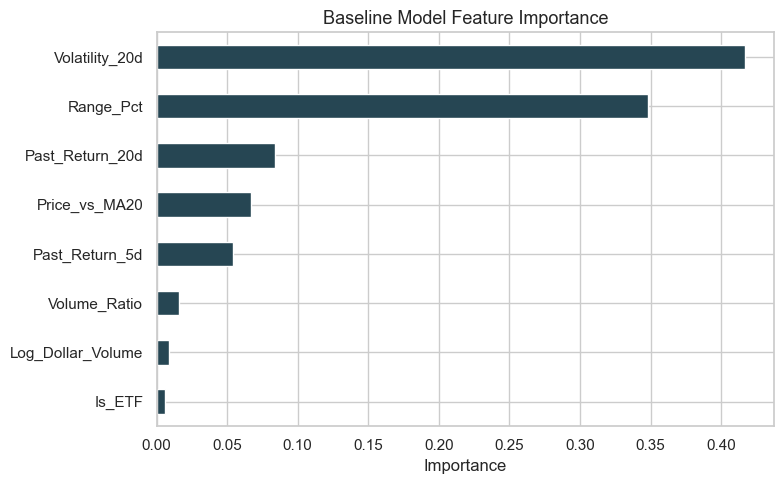

Feature importance (descending):
Volatility_20d      0.4166
Range_Pct           0.3480
Past_Return_20d     0.0839
Price_vs_MA20       0.0667
Past_Return_5d      0.0539
Volume_Ratio        0.0162
Log_Dollar_Volume   0.0087
Is_ETF              0.0060


In [19]:
if not hasattr(model, "estimators_"):
    raise ValueError("Model is not fitted yet. Run the previous training cell first.")

feature_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot.barh(color="#264653")
plt.title("Baseline Model Feature Importance", fontsize=13)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Feature importance (descending):")
print(feature_importance.sort_values(ascending=False).round(4).to_string())


## Results and Interpretation


In [20]:
if "roc_auc" not in globals():
    raise ValueError("roc_auc is not defined yet. Run the baseline model training cell first.")

summary_md = f"""
### Plain-Language Conclusion

- In this notebook, **abnormal volume spikes** are defined as days where volume is at least **{VOLUME_SPIKE_THRESHOLD:.1f}x** the prior 20-day average.
- A **major swing within 48 hours** is defined as an absolute close-to-close move of at least **{MAJOR_SWING_THRESHOLD:.0%}** over the next 1 or 2 trading days.
- The major-swing rate after spike days was **{p_spike:.2%}**, compared with **{p_normal:.2%}** after normal-volume days.
- That is an absolute uplift of **{diff:.2%}** and an odds ratio of **{odds_ratio:.2f}**.
- The proportion test p-value was **{p_value_prop:.4g}**, which tells us whether the difference is statistically distinguishable from zero.
- The baseline ML model achieved **ROC AUC = {roc_auc:.3f}** on the held-out time period.

"""

display(Markdown(summary_md))



### Plain-Language Conclusion

- In this notebook, **abnormal volume spikes** are defined as days where volume is at least **2.0x** the prior 20-day average.
- A **major swing within 48 hours** is defined as an absolute close-to-close move of at least **5%** over the next 1 or 2 trading days.
- The major-swing rate after spike days was **16.16%**, compared with **9.13%** after normal-volume days.
- That is an absolute uplift of **7.03%** and an odds ratio of **1.92**.
- The proportion test p-value was **0**, which tells us whether the difference is statistically distinguishable from zero.
- The baseline ML model achieved **ROC AUC = 0.863** on the held-out time period.



## Limitations and Next Steps

### Limitations

1. **48 hours is approximated with two trading days.** This is reasonable for daily data, but it is not true intraday 48-hour market timing.
2. **We filtered to the most liquid securities.** That makes the notebook more reliable and faster, but it means the result is not automatically about every illiquid microcap.
3. **Volume spikes are not causal proof.** Spikes often happen around earnings, macro news, or rebalancing events that may be the real driver of the move.
4. **No transaction costs or trading rules are modeled.** This notebook studies predictiveness, not profitability.


## Dataset Citations (MLA 8)

Marjanovic, Boris. *Price Volume Data for All US Stocks & ETFs*. Kaggle, [https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs](https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs). Accessed 28 Mar. 2026.
